In [7]:
import torchvision
# For image transforms
from torchvision import transforms
# For DATA SET
import torchvision.datasets as datasets
# For Pytorch methods
import torch
import torch.nn as nn
# For Optimizer
import torch.optim as optim
# FOR DATA LOADER
from torch.utils.data import DataLoader

from denoising_diffusion_pytorch import Unet, GaussianDiffusion


In [8]:

# Hyperparameters
LEARNING_RATE = 4e-4
BATCH_SIZE = 128  # Batch size
N_EPOCHS = 50
IMAGE_SIZE = 28
TIME_STEPS = 1000
SAMPLING_TIMESTEPS = 250

In [9]:

# we define a tranform that converts the image to tensor
myTransforms = transforms.Compose([transforms.ToTensor()])

# the MNIST dataset is available through torchvision.datasets
print("loading MNIST digits dataset")
dataset = datasets.MNIST(root="dataset/", transform=myTransforms, download=True)
# let's create a dataloader to load the data in batches
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = datasets.MNIST(root='dataset/', train=False, download=False, transform=myTransforms)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)



loading MNIST digits dataset


In [10]:

DIM = 32
DIM_MULTS = (1, 2, 5)
model = Unet(
    dim = DIM,
    dim_mults = DIM_MULTS,
    flash_attn = False,
    channels = 1
)

diffusion = GaussianDiffusion(
    model,
    image_size = IMAGE_SIZE,
    timesteps = TIME_STEPS,           # number of steps
    sampling_timesteps = SAMPLING_TIMESTEPS    # number of sampling timesteps (using ddim for faster inference [see ddim paper])
)

optim = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)


In [11]:
import os
import matplotlib.pyplot as plt
from torchvision.utils import save_image

# Move model to device (MPS for Apple Silicon, CUDA for Nvidia, or CPU)
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
diffusion.to(device)
print(f"Training on device: {device}")

Training on device: mps


In [ ]:
losses = []

for epoch in range(N_EPOCHS):
    # implement training loop. You get the loss by calling the diffusion function
    # `loss = diffusion(training_images)`
    epoch_loss = 0.0

    for step, (images, _) in enumerate(loader):
        images = images.to(device)
        
        loss = diffusion(images)
        
        # Optimization step
        optim.zero_grad()
        loss.backward()
        optim.step()

        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)

    # Print the loss at the end of each epoch
    print(f"Epoch {epoch + 1}/{N_EPOCHS} | Loss: {loss.item():.4f}")
    

Epoch 1/50 | Loss: 0.0521
Epoch 2/50 | Loss: 0.0457
Epoch 3/50 | Loss: 0.0405
Epoch 4/50 | Loss: 0.0402
Epoch 5/50 | Loss: 0.0383
Epoch 6/50 | Loss: 0.0391
Epoch 7/50 | Loss: 0.0434
Epoch 8/50 | Loss: 0.0398
Epoch 9/50 | Loss: 0.0300
Epoch 10/50 | Loss: 0.0442
Epoch 11/50 | Loss: 0.0415
Epoch 12/50 | Loss: 0.0423
Epoch 13/50 | Loss: 0.0392
Epoch 14/50 | Loss: 0.0311
Epoch 15/50 | Loss: 0.0433
Epoch 16/50 | Loss: 0.0350
Epoch 17/50 | Loss: 0.0413
Epoch 18/50 | Loss: 0.0379
Epoch 19/50 | Loss: 0.0406
Epoch 20/50 | Loss: 0.0379
Epoch 21/50 | Loss: 0.0389
Epoch 22/50 | Loss: 0.0424
Epoch 23/50 | Loss: 0.0346
Epoch 24/50 | Loss: 0.0404
Epoch 25/50 | Loss: 0.0304
Epoch 26/50 | Loss: 0.0361
Epoch 27/50 | Loss: 0.0349
Epoch 28/50 | Loss: 0.0346
Epoch 29/50 | Loss: 0.0311
Epoch 30/50 | Loss: 0.0352
Epoch 31/50 | Loss: 0.0311
Epoch 32/50 | Loss: 0.0334
Epoch 33/50 | Loss: 0.0339
Epoch 34/50 | Loss: 0.0389
Epoch 35/50 | Loss: 0.0343
Epoch 36/50 | Loss: 0.0394
Epoch 37/50 | Loss: 0.0367
Epoch 38/5

#### It was took 200 min to train for 50 epochs !!!!

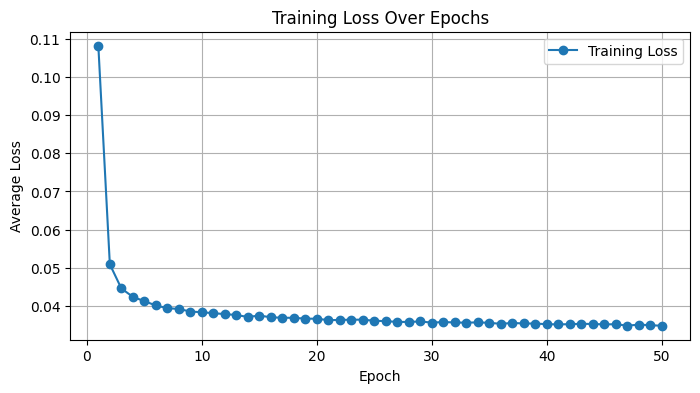

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, N_EPOCHS + 1), losses, marker='o', label='Training Loss')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.grid(True)
plt.legend()
plt.show()

Sampling images and recording all timesteps...


sampling loop time step: 100%|██████████| 250/250 [00:03<00:00, 76.70it/s]


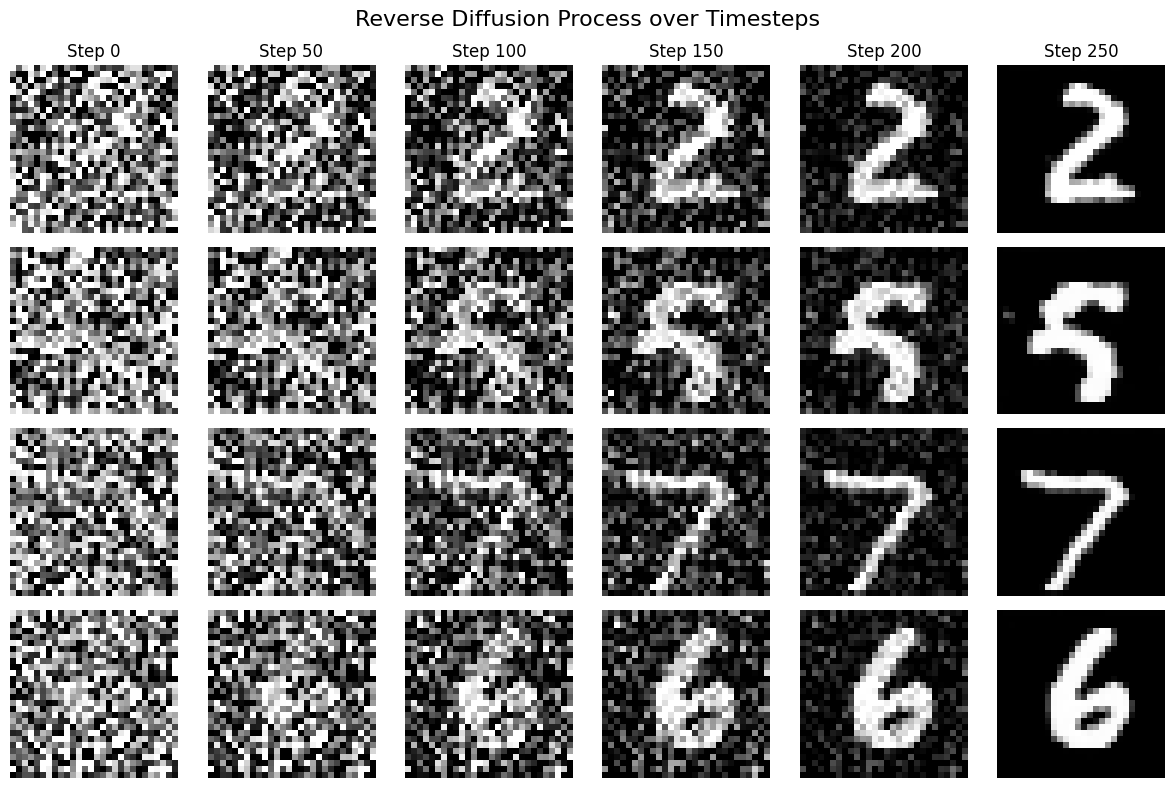

In [17]:
# you can obtain sampled images (i.e. the backward pass) by calling the sample function
# `sampled_images = diffusion.sample(batch_size = 4)`

print("Sampling images and recording all timesteps...")
# Setting return_all_timesteps=True returns shape: (batch_size, num_timesteps, channels, height, width)
all_steps_samples = diffusion.sample(batch_size=4, return_all_timesteps=True)
# Explicitly ensure color amplitudes are kept between 0 and 1
all_steps_samples = torch.clamp(all_steps_samples, 0.0, 1.0).cpu().detach()
# Select a few evenly spaced steps to visualize the reverse diffusion process
num_steps_to_show = 6
total_steps = all_steps_samples.shape[1]
step_indices = torch.linspace(0, total_steps - 1, num_steps_to_show, dtype=torch.long)
fig, axes = plt.subplots(4, num_steps_to_show, figsize=(12, 8))
for i in range(4): # For each image in the batch
    for j, step_idx in enumerate(step_indices):
        ax = axes[i, j]
        # all_steps_samples shape: [batch_idx, time_step, channel, height, width]
        ax.imshow(all_steps_samples[i, step_idx].squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Step {step_idx.item()}")
plt.suptitle("Reverse Diffusion Process over Timesteps", fontsize=16)
plt.tight_layout()
plt.show()


Saved final generated images to generated_images/sample.png


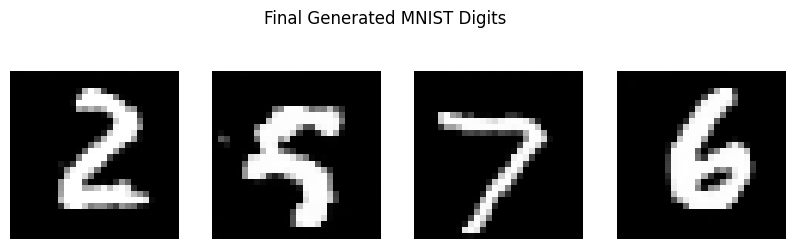

In [18]:
# ---------------------------------------------------------
# 3. Final Generated Result Plot
# ---------------------------------------------------------
# Extract the very last step for the final generated images
final_samples = all_steps_samples[:, -1]  
# Create a folder to save the generated images (Adhering to the rule to save files)
output_dir = "generated_images"
os.makedirs(output_dir, exist_ok=True)
save_image(final_samples, os.path.join(output_dir, "sample.png"), nrow=2)
print(f"Saved final generated images to {output_dir}/sample.png")
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(final_samples[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
plt.suptitle("Final Generated MNIST Digits")
plt.show()
